In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"athashreesankhe","key":"04656f09617623f7995b802d8b78b274"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d tongpython/cat-and-dog
!unzip -q cat-and-dog.zip

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 69% 151M/218M [00:00<00:00, 1.58GB/s]
100% 218M/218M [00:00<00:00, 867MB/s] 


In [5]:
!ls /content

cat-and-dog.zip		   fruits-360_meta	     fruits.zip   test_set
fruits-360_100x100	   fruits-360_multi	     kaggle.json  training_set
fruits-360_3-body-problem  fruits-360_original-size  sample_data


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
train_path = "/content/training_set/training_set"
test_path = "/content/test_set/test_set"

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 6404 images belonging to 2 classes.
Found 1601 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [9]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,563,713 (36.48 MB)

 Trainable params: 9,563,713 (36.48 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.4966 - loss: 0.7517 - val_accuracy: 0.5634 - val_loss: 0.6850
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.5679 - loss: 0.6776 - val_accuracy: 0.6521 - val_loss: 0.6232
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.6841 - loss: 0.6038 - val_accuracy: 0.6858 - val_loss: 0.5761
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.7312 - loss: 0.5259 - val_accuracy: 0.7414 - val_loss: 0.5128
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.7980 - loss: 0.4339 - val_accuracy: 0.7470 - val_loss: 0.5226
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.8325 - loss: 0.3776 - val_accuracy: 0.7733 - val_loss: 0.5052
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.8869 - loss: 0.2868 - val_accuracy: 0.7783 - val_loss: 0.4953
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.9253 - loss: 0.1896 - val_accurac

In [12]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7509 - loss: 0.9047
Test Accuracy: 0.7553138732910156


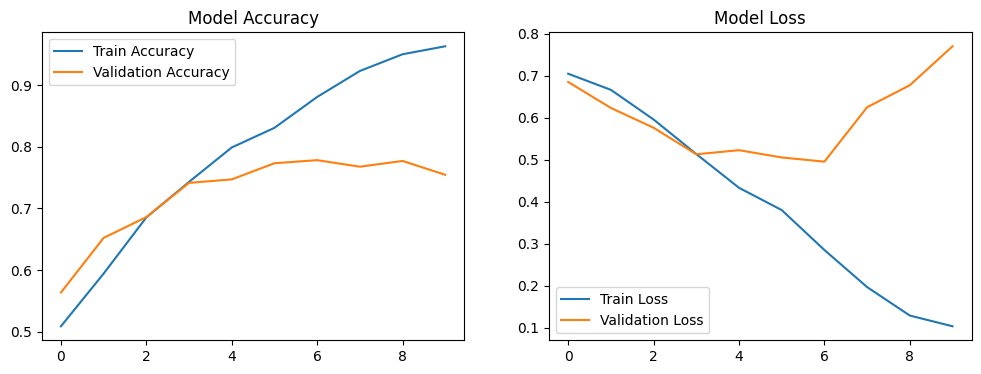

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step


/tmp/ipython-input-938/1615010894.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title("Pred: " + class_names[int(predicted_classes[i])])


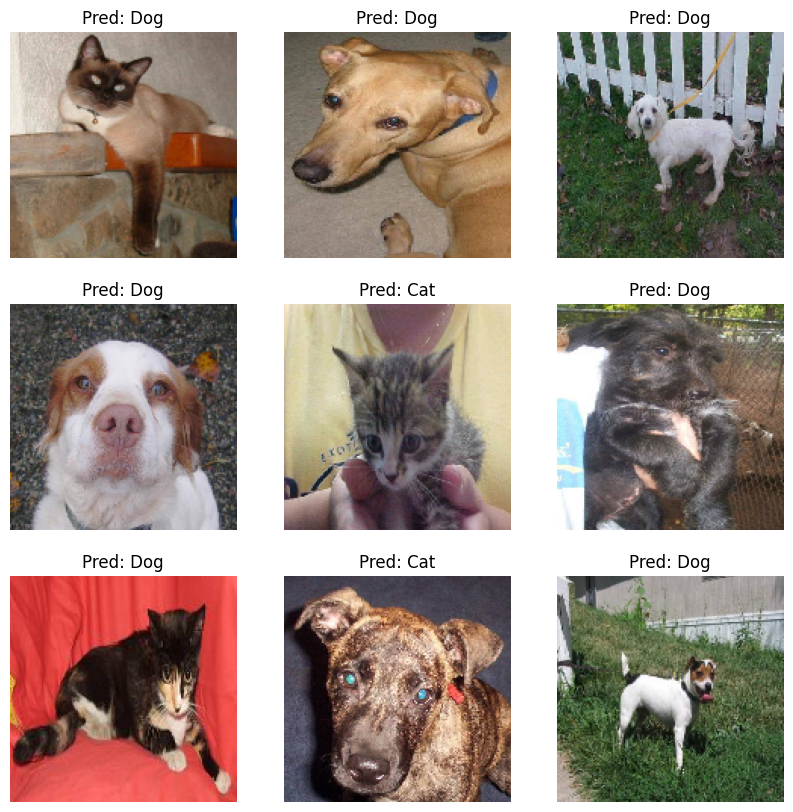

In [14]:
class_names = ["Cat", "Dog"]

images, labels = next(test_generator)

predictions = model.predict(images)
predicted_classes = (predictions > 0.5).astype(int)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("Pred: " + class_names[int(predicted_classes[i])])
    plt.axis('off')

plt.show()